# 1. import libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2) load datasets

In [19]:
df = pd.read_csv(r"C:\Users\gagan\Downloads\healthcare_claims_large.csv")

df.head()

,Claim_ID,Patient_Age,Gender,Provider,Diagnosis,Procedure,Claim_Amount,Hospital_Charges,State,Policy_Type,Claim_Status
0,C00001,72,Male,P003,D002,PR003,30785,3732,RJ,Basic,Approved
1,C00002,78,Male,P002,D005,PR005,23057,4942,AP,Standard,Approved
2,C00003,66,Female,P005,D003,PR002,43002,61853,DL,Standard,Approved
3,C00004,69,Female,P004,D002,PR004,14719,99084,GJ,Standard,Approved
4,C00005,19,Female,P001,D001,PR004,44506,11429,UP,Premium,Approved


# 3) basic info

In [8]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Claim_ID          5000 non-null   object
 1   Patient_Age       5000 non-null   int64 
 2   Gender            5000 non-null   object
 3   Provider          5000 non-null   object
 4   Diagnosis         5000 non-null   object
 5   Procedure         5000 non-null   object
 6   Claim_Amount      5000 non-null   int64 
 7   Hospital_Charges  5000 non-null   int64 
 8   State             5000 non-null   object
 9   Policy_Type       5000 non-null   object
 10  Claim_Status      5000 non-null   object
dtypes: int64(3), object(8)
memory usage: 429.8+ KB


,Patient_Age,Claim_Amount,Hospital_Charges
count,5000.000000,5000.000000,5000.000000
mean,53.364000,25069.279800,50926.208000
std,20.680277,14220.892016,28662.563987
min,18.000000,501.000000,2002.000000
25%,35.000000,12908.500000,26281.250000
50%,53.000000,25028.000000,50515.500000
75%,71.000000,37486.500000,76140.500000
max,89.000000,49989.000000,99984.000000


# 4) check missing value

In [9]:
df.isnull().sum()

Claim_ID            0
Patient_Age         0
Gender              0
Provider            0
Diagnosis           0
Procedure           0
Claim_Amount        0
Hospital_Charges    0
State               0
Policy_Type         0
Claim_Status        0
dtype: int64

# 5) data cleaning

In [21]:
# Fill missing values
df.fillna(method='ffill', inplace=True)

# Drop ID column
df.drop("Claim_ID", axis=1, inplace=True)

C:\Users\gagan\AppData\Local\Temp\ipykernel_16780\857487320.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


# 6) data visulation EDA 

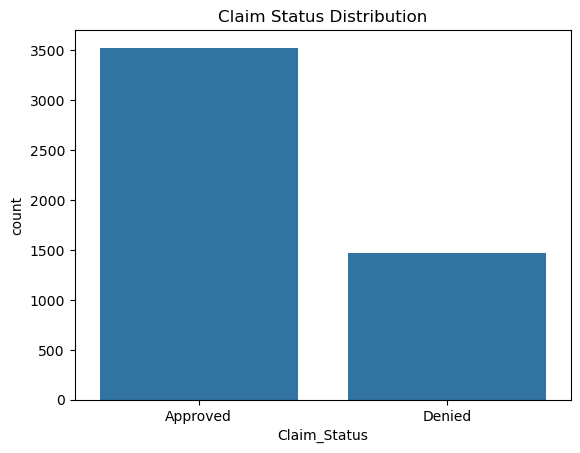

In [11]:
sns.countplot(x="Claim_Status", data=df)
plt.title("Claim Status Distribution")
plt.show()

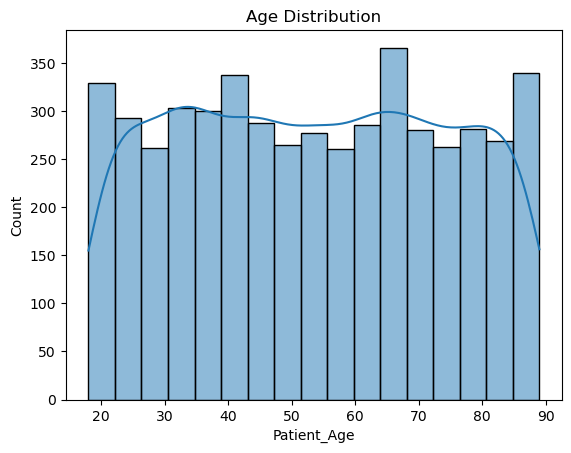

In [12]:
sns.histplot(df["Patient_Age"], kde=True)
plt.title("Age Distribution")
plt.show()

# 7) convert categorical data

In [22]:
df = pd.get_dummies(df, drop_first=True)

In [25]:
df.columns

Index(['Patient_Age', 'Claim_Amount', 'Hospital_Charges', 'Gender_Male',
       'Provider_P002', 'Provider_P003', 'Provider_P004', 'Provider_P005',
       'Diagnosis_D002', 'Diagnosis_D003', 'Diagnosis_D004', 'Diagnosis_D005',
       'Procedure_PR002', 'Procedure_PR003', 'Procedure_PR004',
       'Procedure_PR005', 'State_DL', 'State_GJ', 'State_KA', 'State_MH',
       'State_MP', 'State_RJ', 'State_TN', 'State_UP', 'State_WB',
       'Policy_Type_Premium', 'Policy_Type_Standard', 'Claim_Status_Denied'],
      dtype='object')

In [35]:
# Step 1: Clean all column names
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Step 2: Check columns
print(df.columns)

Index(['patient_age', 'claim_amount', 'hospital_charges', 'gender_male',
       'provider_p002', 'provider_p003', 'provider_p004', 'provider_p005',
       'diagnosis_d002', 'diagnosis_d003', 'diagnosis_d004', 'diagnosis_d005',
       'procedure_pr002', 'procedure_pr003', 'procedure_pr004',
       'procedure_pr005', 'state_dl', 'state_gj', 'state_ka', 'state_mh',
       'state_mp', 'state_rj', 'state_tn', 'state_up', 'state_wb',
       'policy_type_premium', 'policy_type_standard', 'claim_status_denied'],
      dtype='object')


# 8) define featrues and targets

In [37]:
X = df.drop("claim_status_denied", axis=1)
y = df["claim_status_denied"]

In [39]:
print(df.columns.tolist())

['patient_age', 'claim_amount', 'hospital_charges', 'gender_male', 'provider_p002', 'provider_p003', 'provider_p004', 'provider_p005', 'diagnosis_d002', 'diagnosis_d003', 'diagnosis_d004', 'diagnosis_d005', 'procedure_pr002', 'procedure_pr003', 'procedure_pr004', 'procedure_pr005', 'state_dl', 'state_gj', 'state_ka', 'state_mh', 'state_mp', 'state_rj', 'state_tn', 'state_up', 'state_wb', 'policy_type_premium', 'policy_type_standard', 'claim_status_denied']


# 9) Train_test_split

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 10) Train_the_model

In [42]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 11) Prediction_Accuracy

In [43]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.68
              precision    recall  f1-score   support

       False       0.69      0.98      0.81       690
        True       0.19      0.01      0.02       310

    accuracy                           0.68      1000
   macro avg       0.44      0.50      0.41      1000
weighted avg       0.53      0.68      0.56      1000



# 12) Featrues_importance

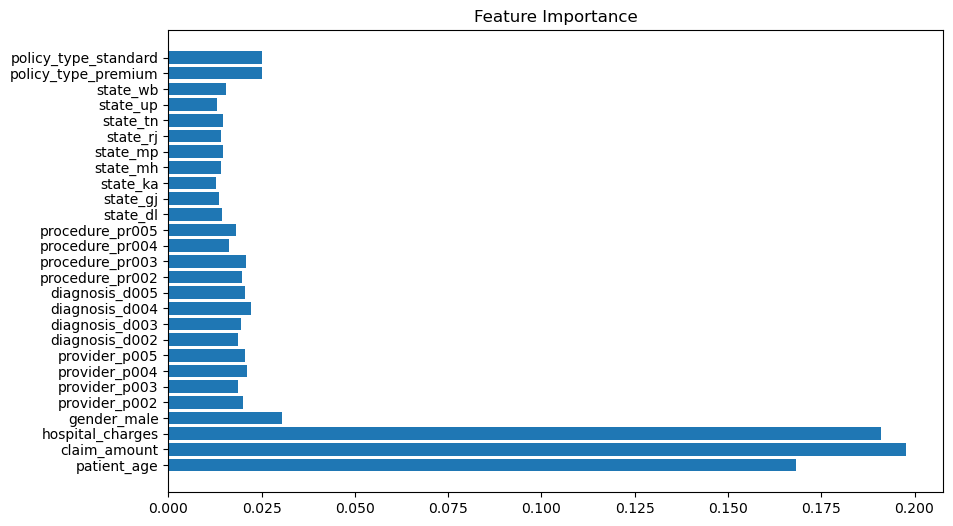

In [44]:
importances = model.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

# 13)  Save_model

In [45]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']